# Private SpiderBoost on one-hot Criteo

Private SpiderBoost (Algorithm 2 of the variance-reduced private ERM line;
`dimma.algorithms.spiderboost`) run **by itself** on Criteo click-through data
and swept over its own knobs. The SpiderBoost-vs-DP-SGD comparison put it head
to head against DP-SGD and tuned it only as far as that comparison needed; this
is the dedicated single-algorithm sweep that `tuning/` exists for (ADR-0019's
folder split), and it sweeps the three axes the algorithm actually has:

- **the phase size** `anchor_interval`, Algorithm 2's `q` — how often the
  running gradient estimate is re-anchored, and so how the budget is split
  between the algorithm's two branches. An interval of 1 makes every step an
  anchor step and the algorithm degenerates into *unclipped noisy SGD*, so the
  grid runs from that degenerate end up through the interior;
- **the two expected batch sizes** `b1` (anchor branch) and `b2` (variation
  branch), with **the noise scales recalibrated by the accountant at every grid
  point** so that each row costs the same ε. The sweep moves the mechanism at a
  constant budget; it never moves the budget;
- **the step size**, with Theorem B.3's `1/(2·L1)` marked on the axis rather
  than assumed. The SpiderBoost-vs-DP-SGD comparison contrasted the selected
  value against the paper's; here the whole axis is visible on both sides of it.

**The encoding is one-hot, and that is what changed.** An earlier execution of
this file ran `load_criteo(features="all")`, where each of `C1..C26` collapses
to one float — the relative frequency of its category in the training split —
and so two equally-common categories become the same number. This one runs
`load_criteo_one_hot` (ADR-0020): 26 categorical columns one-hot at their
native train-split cardinalities, 551,947 coordinates, and a row handed back as
the 39 indices it occupies rather than as a dense vector costing 2.2 TB across
the file. The encoding comparison is what says that choice is worth paying for.

**Moving it breaks a tie this file used to lean on, and the break is real.**
The budget and the loader call used to be the SpiderBoost-vs-DP-SGD
comparison's verbatim, so that a configuration selected here transferred there.
That comparison is a dense one and is not being moved, so what transfers now is
the protocol and not the representation: same target **ε = 3, δ = 1e-6**, same
accountant (**RDP**, ADR-0011), same enforced feature norm bound **R = 2.0**
(ADR-0012), same **700,000 / 100,000** train/validation split sizes cut by the
same rule from the same 800,000 rows — but a different feature space, so the
closing compares the two as two encodings rather than as one result confirmed
twice.

**The dense sweep's winner is not in this grid, and could not be.** That
execution selected `b1 = 16,384`; per-example gradients at that anchor batch
are `16,384 × 551,947` float32, about 36 GB, against the 31.5 GB this shared
card hands out at the memory fraction below — and the padded cap the sampler
actually allocates is larger than `b1` again. The batch axis therefore stops at
`b1 = 8,192` here — a limit of the
encoding rather than a choice — which matters because this file's one clear
finding is that the phase size and the anchor batch are a single axis. Section
7 reads the sweep in that light.

**The cut is not that comparison's rows, and saying so matters.** This file
runs on its own stream root, `BASE_SEED = 20260823`, so the permutation and the
100,000 rows held out are its own. The *test* split is the loader's
deterministic `seed=0` / `test_fraction=0.2` cut, identical across every
notebook that loads this file, which is where results are compared. What
transfers is a configuration and a protocol, not a validation number.

**The step count is a compromise, and the encoding made it a larger one.**
Every run here is **2,000 optimizer steps**, so that the grid fits the
wall-clock this notebook is allowed. A one-hot SpiderBoost step costs 14 ms at
the bottom of the batch axis and 25 ms at the top, against the dense
execution's under 2, so the grid itself is smaller than that execution's 200
runs as well; section 3 states exactly which points were dropped and why. The budget is recalibrated over exactly the
2,000 steps that run, so every row is a complete run at ε = 3 rather than a
truncated one. Whether a 2,000-step run reaches the level a 10,000-step run
reaches is then a question, not an assumption, and section 6 answers it by
measurement.

**The ε here is assumed, not enforced.** Algorithm 2 has no clipping line and
dimma adds none (ADR-0009): the guarantee holds only if the shipped per-sample
BCE really is `L0`-Lipschitz and `L1`-smooth with the constants its noise was
calibrated against, and those constants come from `R` and the bias flag alone
(ADR-0012). Nothing in this notebook and nothing in the library checks that.

> ### The run this file carries
>
> **The outputs stored here are the full configuration**, `SMOKE = False`:
> **2,000 optimizer steps** per run, **60 runs** in the grid — 5 phase sizes ×
> 4 batch pairs × 3 step sizes — a **7-point** step-count trajectory reaching
> 10,000 steps at the selected configuration, and **5 seed repeats** at each of
> two configurations, every one of them calibrated to **ε = 3, δ = 1e-6** by
> RDP over exactly the steps it ran. Every number below is read off this
> execution and the closing section is written against it.
>
> That grid is smaller than the dense execution's 200 runs, and section 3 names
> every point dropped and the reason. A trimmed grid that reads as full
> coverage would be the worst outcome here, so the counts are stated in both
> places and the figures label the axes they actually swept.
>
> The configuration block carries a `SMOKE` switch which shortens the step
> count, the three grid axes, the trajectory and the seed list — and nothing
> else. It is a development convenience; it is not what this file was run with.

### The library this notebook ran against

Printed rather than assumed. `dimma.metrics.ranking` and
`dimma.metrics.operating_point` carry the PR curve and the operating-point
code; there is no local copy of either here, and a checkout without them has
nothing to fall back on.

In [1]:
import os

# Set before jax touches the device. This notebook runs several training
# loops concurrently on one GPU (section 3), so the allocator is asked for
# a fixed large fraction up front rather than being left to grow under a
# pool that is already in flight. Below the dense execution's 0.8 because
# this card is shared and the fraction is of the whole device: one that
# assumes an empty card fails here, at import, rather than at the first
# large allocation.
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.62")

import time
from concurrent.futures import ThreadPoolExecutor
from typing import NamedTuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import dimma
from dimma.accounting import spiderboost as spiderboost_accounting
from dimma.accounting.lipschitz import logreg_bce_constants
from dimma.algorithms.spiderboost import train as spiderboost
from dimma.core import updates
from dimma.core.sampling import poisson
from dimma.datasets.criteo import load_criteo_one_hot
from dimma.metrics import operating_point, ranking
from dimma.metrics.calibration import (
    calibration_ratio,
    expected_calibration_error,
)
from dimma.metrics.operating_point import best_f1_threshold, confusion_at
from dimma.metrics.ranking import pr_curve
from dimma.metrics.scoring import log_loss, normalized_entropy
from dimma.models.logreg import forward_sparse, init_params

print("dimma:", dimma.__file__)
assert hasattr(ranking, "pr_curve"), "this checkout predates dimma.metrics.ranking"
assert hasattr(operating_point, "confusion_at"), (
    "this checkout predates dimma.metrics.operating_point")
print("dimma.metrics.ranking and dimma.metrics.operating_point: present")

# The one device handle, read once and reused: section 3 sizes its thread
# pool off this object's memory statistics.
DEVICES = jax.devices()
DEVICE = DEVICES[0]
DEVICE_KIND = "gpu" if any(d.platform == "gpu" for d in DEVICES) else "cpu"
print(f"jax devices: {DEVICES}  ->  DEVICE_KIND = {DEVICE_KIND!r}")

dimma: /home/diegol/dimma_lib/.claude/worktrees/one-hot-encoding/src/dimma/__init__.py
dimma.metrics.ranking and dimma.metrics.operating_point: present


jax devices: [CudaDevice(id=0)]  ->  DEVICE_KIND = 'gpu'


### The configuration block

One block. **The budget, `R`, the accountant, the bin count and the seeds are
the protocol and do not move**; `SMOKE` switches the step count, the three grid
axes, the trajectory and the seed list, and nothing else.

The three grid axes are stated here rather than derived. The phase size runs
from **1**, where Algorithm 2 degenerates into unclipped noisy SGD, up to
**128**; the batch pair holds `b1 / b2 = 4` — the SpiderBoost-vs-DP-SGD
comparison's ratio — and doubles from 1,024 to **8,192**, one octave short of
the dense execution because the pair above it does not fit; the step size is
stated in **multiples of Theorem B.3's `1/(2·L1)`**, so the paper's value is
the entry at multiple 1 and is a point on the axis rather than a separate
experiment.

**Interiority is a weaker claim here than it was.** Each axis is thinner than
the dense execution's, and the batch axis is truncated at the top rather than
bounded by a choice, so a winner at `b1 = 8,192` is on an edge that exists for
a hardware reason. Section 7 says so where it matters rather than reporting an
interior optimum this grid cannot establish.

In [2]:
SMOKE = False

# ---- the protocol, kept from the dense execution so the two are readable. -
TARGET_EPSILON = 3.0
TARGET_DELTA = 1e-6
FEATURE_NORM_BOUND = 2.0        # ADR-0012's R, fixed a priori, never fitted
ACCOUNTANT = "rdp"              # ADR-0011
N_BINS = 15                     # equal-mass bins, as notebooks 01, 02 and 05
VALIDATION_ROWS = 100_000       # the deterministic cut of the training split
INIT_SEED = 0                   # the one initialization, every run in the file
PADDING_MARGIN_SIGMAS = 8.0     # ADR-0007; see the padding-cap note in 3

# This notebook's own stream roots, all in one place. BASE_SEED is
# this file's own, so no run here silently reproduces one from another
# notebook; the two offsets keep the seed repeats and the trajectory clear of
# the grid's own seed indices, which are positions in the grid.
BASE_SEED = 20260823
REPEAT_SEED_BASE = 10_000
TRAJECTORY_SEED_BASE = 20_000

# ---- what SMOKE moves, and all it moves. --------------------------------
if SMOKE:
    STEPS = 200
    ANCHOR_INTERVAL_GRID = (1, 16, 128)
    BATCH_GRID = ((1024, 256), (4096, 1024))
    STEP_SCALE_GRID = (1.0, 16.0)
    TRAJECTORY_STEPS = (50, 100, 200, 400)
    SEEDS = (0, 1)
else:
    STEPS = 2_000
    # Five of the dense execution's eight phase sizes. The span is kept end
    # to end -- q = 1, where Algorithm 2 degenerates into unclipped noisy
    # SGD, through q = 128 -- because the finding this axis carries is the
    # slope across it at a small anchor batch, and a slope needs the ends
    # more than it needs the middle. Dropped: 2, 8 and 32.
    ANCHOR_INTERVAL_GRID = (1, 4, 16, 64, 128)
    # Four of five batch pairs. (16384, 4096) is not a choice: per-example
    # gradients at that anchor batch are 16,384 x 551,947 float32, about
    # 36 GB, against the 31.5 GB this card hands out at the fraction above.
    # It is the pair the dense execution selected, and section 7 reads the
    # sweep knowing its winner is out of reach.
    BATCH_GRID = ((1024, 256), (2048, 512), (4096, 1024),
                  (8192, 2048))                         # (b1, b2), ratio 4
    # Three of five step sizes: the paper's value, the dense execution's
    # selected 16x, and the 64x at which that execution resolved a collapse.
    # Dropped: 0.25 and 4.0, both interior points whose differences the
    # dense execution could not resolve against its own seed spread.
    STEP_SCALE_GRID = (1.0, 16.0, 64.0)                 # x Theorem B.3's value
    TRAJECTORY_STEPS = (125, 250, 500, 1_000, 2_000, 4_000, 10_000)
    # Five, not three. On this encoding the seed spread turns out to be the
    # largest quantity in the file -- wider than most of the grid it is used
    # to judge -- so it is the last thing to economise on.
    SEEDS = (0, 1, 2, 3, 4)

GRID_SIZE = (len(ANCHOR_INTERVAL_GRID) * len(BATCH_GRID)
             * len(STEP_SCALE_GRID))
SHAPE_COUNT = len(ANCHOR_INTERVAL_GRID) * len(BATCH_GRID)

print(f"SMOKE = {SMOKE}")
print(f"  steps per grid run   : {STEPS:,}")
print(f"  phase sizes q        : {ANCHOR_INTERVAL_GRID}")
print(f"  batch pairs (b1, b2) : {BATCH_GRID}")
print(f"  step sizes           : {STEP_SCALE_GRID} x Theorem B.3's 1/(2*L1)")
print(f"  grid                 : {GRID_SIZE} runs over {SHAPE_COUNT} "
      f"distinct (q, b1, b2) shapes, each shape calibrated once")
print(f"  trajectory           : {TRAJECTORY_STEPS}")
print(f"  seed repeats         : {SEEDS}")
print(f"  budget               : epsilon = {TARGET_EPSILON:g}, "
      f"delta = {TARGET_DELTA}, method {ACCOUNTANT!r}, recalibrated over "
      f"exactly the steps each run takes")

SMOKE = False
  steps per grid run   : 2,000
  phase sizes q        : (1, 4, 16, 64, 128)
  batch pairs (b1, b2) : ((1024, 256), (2048, 512), (4096, 1024), (8192, 2048))
  step sizes           : (1.0, 16.0, 64.0) x Theorem B.3's 1/(2*L1)
  grid                 : 60 runs over 20 distinct (q, b1, b2) shapes, each shape calibrated once
  trajectory           : (125, 250, 500, 1000, 2000, 4000, 10000)
  seed repeats         : (0, 1, 2, 3, 4)
  budget               : epsilon = 3, delta = 1e-06, method 'rdp', recalibrated over exactly the steps each run takes


### Chart styling

Every figure in this file plots one *ordered* quantity against another — a
phase size, a batch size, a step size, a step count — so the line colour
carries an **ordinal ramp**, one hue light to dark, low value to high. It is
never a categorical palette: these series have an order and the colour says so.
The ramp's lightest step sits under 3:1 against the surface, which is why every
figure below is followed by the table of the numbers it draws, and why every
panel is labelled by a legend as well as by hue.

In [3]:
# One blue hue, light to dark, low to high. Validated as an ordinal ramp
# against this surface: monotone in lightness, adjacent steps separated,
# light end clear of the surface.
RAMP_5 = ("#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b")
RAMP_4 = ("#86b6ef", "#3987e5", "#256abf", "#0d366b")
ACCENT = "#2a78d6"              # the single-series colour
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": MUTED,
    "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "lines.linewidth": 2.0, "lines.markersize": 6.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "font.size": 10,
})

## 1. The data, and the split the sweep is selected on

All 39 features — the 13 integer columns and the 26 categorical ones — the
preprocessing chain, the deterministic `seed=0` / `test_fraction=0.2` split, on
GPU, from the cached full file, with the feature norm bound `R = 2.0`
**enforced** by the loader (ADR-0012). The categorical 26 arrive one-hot at
their native train-split cardinalities, so the split comes back as index/value
pairs and a width rather than as a matrix (ADR-0020).

There is **no `standardize` argument to pass**. ADR-0020 declines the axis
because centring a one-hot column fills it, and the sparsity is what makes the
encoding fit at all; the dense execution of this file standardized, so that is
one more thing that differs between the two and one more reason the closing
compares them as two encodings rather than as one result run twice.

The 800,000-row training split is then cut once, deterministically, into
**700,000 train / 100,000 validation**. Every run in the sweep trains on the
same 700,000 rows and is selected on the same 100,000, so `n = 700,000` and
every sampling rate below is `b / 700,000`. The test split is not read until
section 7.

In [4]:
split = load_criteo_one_hot(preprocess=True, download=False, seed=0,
                            device=DEVICE_KIND,
                            feature_norm_bound=FEATURE_NORM_BOUND)

# 39 stored entries a row whatever the record holds, which is a property of
# the encoding rather than of the data -- ADR-0020's whole point.
STORED_PER_ROW = split.idx_train.shape[1]
n_all, n_features = split.idx_train.shape[0], split.num_features

# One deterministic cut of the training split: a permutation at a fixed
# seed, held out once and never re-drawn.
holdout = np.random.default_rng(BASE_SEED).permutation(n_all)
val_index = jnp.asarray(holdout[:VALIDATION_ROWS])
train_index = jnp.asarray(holdout[VALIDATION_ROWS:])

# A dimma per-sample loss is `(params, x_single, y_single) -> scalar` and a
# training loop slices its `x` along one leading axis, so the pair a sparse
# row arrives in has to travel as one: the first 39 columns are the indices,
# the last 39 the values. The DP-SGD sweep's cell, and the bias-reduced-SGD
# sweep's. Indices go through float32 exactly -- the widest is 551,946, well
# inside the 16,777,216 where float32 stops counting by ones.
PACKED_TRAIN = jnp.concatenate(
    [split.idx_train.astype(jnp.float32), split.val_train], axis=1
)
assert (np.asarray(PACKED_TRAIN[:, :STORED_PER_ROW]).astype(np.int64)
        == np.asarray(split.idx_train)).all(), "index round-trip"


def per_sample_sparse_bce(params, packed, y):
    """BCE for one example held as concatenated indices and values.

    `dimma.models.losses.per_sample_bce_loss` composes with the dense
    forward; this is the same overflow-safe rearrangement over the sparse
    one, and it computes the same logit from the pair a dense row implies.
    """
    idx = packed[:STORED_PER_ROW].astype(jnp.int32)
    logit = forward_sparse(params, idx, packed[STORED_PER_ROW:])
    return jax.nn.softplus(logit) - logit * y


_score = jax.jit(jax.vmap(
    lambda params, packed: forward_sparse(
        params, packed[:STORED_PER_ROW].astype(jnp.int32),
        packed[STORED_PER_ROW:]),
    in_axes=(None, 0)))

X_TRAIN, Y_TRAIN = PACKED_TRAIN[train_index], split.y_train[train_index]
X_VAL, Y_VAL = PACKED_TRAIN[val_index], split.y_train[val_index]
# Bound here so the loader's arrays can be released, and not read until
# section 7 — not even for its base rate.
X_TEST = jnp.concatenate(
    [split.idx_test.astype(jnp.float32), split.val_test], axis=1
)
Y_TEST = split.y_test

n_train = X_TRAIN.shape[0]
Y_VAL_NP = np.asarray(Y_VAL, dtype=np.float64)
VAL_BASE_RATE = float(Y_VAL_NP.mean())

print(f"train {X_TRAIN.shape}   val {X_VAL.shape}   test {X_TEST.shape} "
      f"(test bound, unread)")
print(f"label base rate: {float(Y_TRAIN.mean()):.4f} train, "
      f"{VAL_BASE_RATE:.4f} val")
print(f"validation PR-AUC floor (a random ranking scores the base rate): "
      f"{VAL_BASE_RATE:.4f}")
print(f"arrays live on: {list(X_TRAIN.devices())}")
print()
print(f"enforced feature norm bound R = {split.metadata['feature_norm_bound']}")
print()
print(split.metadata["preprocessing"])

# The loader's own train arrays are the largest objects on the device and
# nothing below reads them again — the four arrays above are gathers, not
# views. Dropped so the run's device footprint is what the run uses, which
# is also what section 3 sizes its thread pool against.
del split, holdout, train_index, val_index

criteo: 39 features as index/value pairs. I1-I13 at indices 0-12: NaN filled with the train-split median, clipped below at 0, then log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26 one-hot at their native train-split cardinalities, each column holding its own block of the index space and one slot reserved for IDs unseen in the training split, so every row carries exactly 39 entries whatever it holds. Not standardized: centring a one-hot column fills it, and the sparsity is the point. Every row then rescaled to l2 norm at most 2.0, one record at a time.


train (700000, 78)   val (100000, 78)   test (200000, 78) (test bound, unread)
label base rate: 0.2510 train, 0.2506 val
validation PR-AUC floor (a random ranking scores the base rate): 0.2506
arrays live on: [CudaDevice(id=0)]

enforced feature norm bound R = 2.0

39 features as index/value pairs. I1-I13 at indices 0-12: NaN filled with the train-split median, clipped below at 0, then log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26 one-hot at their native train-split cardinalities, each column holding its own block of the index space and one slot reserved for IDs unseen in the training split, so every row carries exactly 39 entries whatever it holds. Not standardized: centring a one-hot column fills it, and the sparsity is the point. Every row then rescaled to l2 norm at most 2.0, one record at a time.


### What `R` buys, and what sits outside every ε below

**For Private SpiderBoost `R` is the budget.** There is no clipping line
(ADR-0009), so the sensitivity bounds come from the assumption that the loss is
`L0`-Lipschitz and `L1`-smooth, and for the shipped logistic regression under
the shipped per-sample BCE those two constants are the largest augmented
feature norm and its square over four — functions of `R` and the bias flag
alone (ADR-0012). `R` therefore fixes both constants, and through them all
three noise scales *and* Theorem B.3's step size. A run at a different `R` is a
different mechanism at the same nominal ε, which is why `R = 2.0` is written
into the configuration block before the file is read: an `R` chosen by looking
at the norms is a fitted `L0`, and an ε calibrated from a fitted `L0` is false
with no crash.

Three accesses sit outside every ε in this notebook (ADR-0008):

1. **The preprocessing statistics** — medians, category frequencies, means and
   standard deviations — are fitted on the training split and charged to no
   budget. The 100,000 validation rows were inside the split they were fitted
   on, which is a second, smaller version of the same leak.
2. **The 200-run sweep is never accounted.** Each row trains a model and has a
   validation loss read off it; the reported ε covers one run.
3. **Evaluating on held-out data is outside the loop by design** — `train`
   returns no metrics, precisely so the loop is not in a position to leak one.

## 2. The constants, and one budget per grid shape

`L0`, `L1` and Theorem B.3's step size come from `R` and the bias flag and from
nothing in the data. **The bias flag is read off the shipped parameter tree
rather than defaulted**: the augmented norm is `‖x‖² + 1` when the model carries
a bias, which moves `L1`, the step size and every noise scale, and a wrong flag
reports an ε that is simply false.

In [5]:
# The parameter pytree is {"w": (d,), "b": ()}, so this model carries a bias.
PROBE_PARAMS = init_params(jax.random.key(INIT_SEED), n_features)
HAS_BIAS = "b" in PROBE_PARAMS
assert HAS_BIAS, "the shipped logreg carries a bias; a wrong flag is a false epsilon"

CONSTANTS = logreg_bce_constants(FEATURE_NORM_BOUND, has_bias=HAS_BIAS)
PAPER_STEP_SIZE = CONSTANTS.step_size

print(f"R = {FEATURE_NORM_BOUND}, has_bias = {HAS_BIAS}  (read off the model)")
print(f"  L0 (Lipschitz)  = {CONSTANTS.lipschitz_constant:.6f}")
print(f"  L1 (smoothness) = {CONSTANTS.smoothness_constant:.6f}")
print(f"  Theorem B.3 step size 1/(2*L1) = {PAPER_STEP_SIZE:.6f}")
print()
print("step sizes on the grid, as multiples of that value:")
for scale in STEP_SCALE_GRID:
    marker = "   <- Theorem B.3" if scale == 1.0 else ""
    print(f"  {scale:>7g} x  ->  eta = {scale * PAPER_STEP_SIZE:.6f}{marker}")

R = 2.0, has_bias = True  (read off the model)
  L0 (Lipschitz)  = 2.236068
  L1 (smoothness) = 1.250000
  Theorem B.3 step size 1/(2*L1) = 0.400000

step sizes on the grid, as multiples of that value:
        1 x  ->  eta = 0.400000   <- Theorem B.3
       16 x  ->  eta = 6.400000
       64 x  ->  eta = 25.600000


### One calibration per shape, not one per run

Private SpiderBoost releases on **two** schedules, composed in one accountant
rather than summed (ADR-0010): `ceil(steps / q)` anchor releases at rate
`b1 / n`, and the remaining `steps - ceil(steps / q)` variation releases at
`b2 / n`. So the budget depends on the run's *shape* — the step count, the
phase size and the two batch sizes — and not at all on the step size, which the
accountant never sees. The 200 grid runs therefore span 40 shapes and take 40
calibrations, each buying the shared multiplier `μ` that turns into the three
scales `μ·L0/b1`, `μ·L1/b2` and `2·μ·L0/b2`.

Those three go to `train` **unconverted**, and the table below also runs the
accountant in the reporting direction — ε recomputed from the very scales the
loop is handed — so a calibration and a report cannot silently disagree.

At `q = 1` every step is an anchor step: the variation branch never runs, `b2`
is inert, and the second schedule composes zero releases. Those five rows are
the degenerate end of the phase-size axis, and they are unclipped noisy SGD
rather than Algorithm 2.

In [6]:
SCALES, EPSILON_BACK = {}, {}


def calibrate(steps, anchor_interval, b1, b2):
    """Fill SCALES and EPSILON_BACK for one run shape.

    Called from the main thread only: the sweep's workers read this cache
    and never write it.
    """
    shape = (steps, anchor_interval, b1, b2)
    if shape in SCALES:
        return SCALES[shape]
    scales = spiderboost_accounting.noise_scales(
        lipschitz_constant=CONSTANTS.lipschitz_constant,
        smoothness_constant=CONSTANTS.smoothness_constant,
        target_epsilon=TARGET_EPSILON, target_delta=TARGET_DELTA,
        steps=steps, anchor_interval=anchor_interval,
        anchor_expected_batch_size=b1, variation_expected_batch_size=b2,
        dataset_size=n_train, method=ACCOUNTANT,
    )
    spent = spiderboost_accounting.epsilon(
        lipschitz_constant=CONSTANTS.lipschitz_constant,
        smoothness_constant=CONSTANTS.smoothness_constant,
        anchor_noise_scale=scales.anchor_noise_scale,
        variation_noise_rate=scales.variation_noise_rate,
        variation_noise_cap=scales.variation_noise_cap,
        target_delta=TARGET_DELTA, steps=steps,
        anchor_interval=anchor_interval,
        anchor_expected_batch_size=b1, variation_expected_batch_size=b2,
        dataset_size=n_train, method=ACCOUNTANT,
    )
    assert spent <= TARGET_EPSILON + 1e-9
    SCALES[shape], EPSILON_BACK[shape] = scales, spent
    return scales


t0 = time.time()
print(f"{'q':>5} {'b1':>7} {'b2':>7} {'anchor':>8} {'variation':>10} "
      f"{'sigma_1':>12} {'sigma_2':>12} {'sigma_2 cap':>12} {'epsilon':>10}")
for b1, b2 in BATCH_GRID:
    for interval in ANCHOR_INTERVAL_GRID:
        scales = calibrate(STEPS, interval, b1, b2)
        anchors, variations = spiderboost_accounting.release_counts(
            STEPS, interval)
        spent = EPSILON_BACK[(STEPS, interval, b1, b2)]
        print(f"{interval:>5} {b1:>7} {b2:>7} {anchors:>8} {variations:>10} "
              f"{scales.anchor_noise_scale:>12.4e} "
              f"{scales.variation_noise_rate:>12.4e} "
              f"{scales.variation_noise_cap:>12.4e} {spent:>10.6f}")
print(f"\n{SHAPE_COUNT} shapes calibrated in {time.time() - t0:.1f}s "
      f"(method {ACCOUNTANT!r}, delta = {TARGET_DELTA}, {STEPS:,} steps)")
print("every epsilon above is the reporting direction, computed back from "
      "the three scales the loop is handed; all land at the target from "
      "below.")

    q      b1      b2   anchor  variation      sigma_1      sigma_2  sigma_2 cap    epsilon


    1    1024     256     2000          0   1.4171e-03   3.1686e-03   1.1336e-02   2.999999


    4    1024     256      500       1500   1.3645e-03   3.0511e-03   1.0916e-02   2.999991


   16    1024     256      125       1875   1.3237e-03   2.9598e-03   1.0589e-02   3.000000


   64    1024     256       32       1968   1.2911e-03   2.8871e-03   1.0329e-02   3.000000


...

    1    8192    2048     2000          0   3.1031e-04   6.9388e-04   2.4825e-03   2.999995


    4    8192    2048      500       1500   2.4551e-04   5.4897e-04   1.9641e-03   3.000000


   16    8192    2048      125       1875   2.2269e-04   4.9795e-04   1.7815e-03   3.000000


   64    8192    2048       32       1968   2.1123e-04   4.7233e-04   1.6899e-03   2.999992


  128    8192    2048       16       1984   2.0721e-04   4.6333e-04   1.6577e-03   2.999998

20 shapes calibrated in 9.7s (method 'rdp', delta = 1e-06, 2,000 steps)
every epsilon above is the reporting direction, computed back from the three scales the loop is handed; all land at the target from below.


## 3. The runner, the streams, the padding caps, and the pool

**One initialization for every run in this file**, `init_params(key(INIT_SEED),
d)`. What moves per run is the sampling stream,
`numpy.random.default_rng([BASE_SEED, i])`, and the noise stream,
`jax.random.key(BASE_SEED + i)`, both folded off a `seed_index` that is the
run's position in the grid — so the sweep reproduces from this file alone, and
so **the seed varies with the configuration**. That last point is a real
confound and it is not swept under the rug: section 5 re-runs two configurations
at five seeds each and reports both spreads, and every interiority and winner
claim below names which of the two it was read against.

**The padding caps are chosen, not defaulted.** A Poisson draw has
data-dependent cardinality, so each branch pads to a cap and an oversize draw
**raises** — truncating would make inclusion dependent across examples and void
the amplification the accountant assumes (ADR-0007). The library default is a
6-sigma margin, roughly 1e-9 per draw; over 2,000 draws per branch across 60
runs that is a file that can die near its end for no scientific reason, so the
margin is **8 sigmas** and the caps are computed **separately for the two
branches** — the anchor batch is four times the variation batch, and one cap for
both would spend an `O(b1)` batch on every variation step. If a run raises, the
cap goes up and the run is repeated; the exception is never caught.

**The runs are threaded, and that is a wall-clock decision with no effect on
any number.** Each run is an independent `train` call over its own streams, so
running several at once changes nothing about what any one of them computes.

**On this encoding the memory bound is the binding one, which reverses the
dense execution's reasoning.** There it noted that a 39-feature step is
dominated by dispatch, that the memory bound came out in the hundreds of
concurrent runs, and that a chosen ceiling of eight cost nothing. Here Algorithm
2 has no clipping line but `jax.grad` still returns a dense row per example, so
a step at anchor batch `b1` allocates `cap_for(b1) × 551,947` float32 — 2.5 GB
at `b1 = 1,024` and 18 GB at `b1 = 8,192`. The pool below is sized from the
device's own reported limit against that footprint and so **shrinks to one at
the top of the batch axis**, which is arithmetic and not a preference.

Concurrency also buys much less than it did. Six concurrent runs at
`b1 = 1,024` return about 1.6 times one run's throughput rather than six, so the
card is genuinely busy rather than waiting on dispatch. That measurement is why
the grid above is 60 runs and not 200: at 14 to 25 ms a step against the dense
execution's under 2, no pool size available here makes the full grid fit.

In [7]:
def cap_for(expected_batch_size):
    """This run's padding cap for one branch. Not a privacy parameter."""
    return poisson.padded_batch_size(expected_batch_size, n_train,
                                     margin_sigmas=PADDING_MARGIN_SIGMAS)


def fresh_params():
    """The one starting point, shared by every run in this notebook."""
    return init_params(jax.random.key(INIT_SEED), n_features)


def noise_key(seed_index):
    return jax.random.key(BASE_SEED + seed_index)


def sampling_rng(seed_index):
    return np.random.default_rng([BASE_SEED, seed_index])


class Config(NamedTuple):
    """One point of the grid, and the stream it runs on."""

    anchor_interval: int
    b1: int
    b2: int
    step_scale: float
    """Multiples of Theorem B.3's 1/(2*L1); 1.0 is the paper's value."""
    seed_index: int

    @property
    def step_size(self):
        return self.step_scale * PAPER_STEP_SIZE


class Eval(NamedTuple):
    """What one run is scored on. All three are threshold-free."""

    loss: float
    pr_auc: float
    ece: float


class Axis(NamedTuple):
    """One axis of the sweep, in the one place that knows it is one.

    Every table, matrix and axis-hold below reads the grid through these
    three objects rather than through a field name spelled out again.
    """

    field: str
    """The `Config` field this axis moves."""
    short: str
    """Column heading, for the matrices."""
    title: str
    """Full name, for the per-axis tables."""
    values: tuple
    """Every value on this axis, in the order the grid lists them."""
    describe: object
    """`Config -> str`: this axis's coordinate at one grid point."""


def phase_label(config):
    return f"{config.anchor_interval}"


def batch_label(config):
    return f"{config.b1} / {config.b2}"


def step_label(config):
    return f"{config.step_scale:g}x = {config.step_size:.4f}"


PHASE_AXIS = Axis(field="anchor_interval", short="q", title="phase size q",
                  values=tuple(ANCHOR_INTERVAL_GRID), describe=phase_label)
BATCH_AXIS = Axis(field="b1", short="b1",
                  title="anchor batch b1 (b2 = b1/4)",
                  values=tuple(b1 for b1, _ in BATCH_GRID),
                  describe=batch_label)
STEP_AXIS = Axis(field="step_scale", short="x paper",
                 title="step size, x Theorem B.3's",
                 values=tuple(STEP_SCALE_GRID), describe=step_label)
AXES = (PHASE_AXIS, BATCH_AXIS, STEP_AXIS)


class Row(NamedTuple):
    """One grid point and its validation score."""

    config: Config
    scores: Eval


class TrajectoryJob(NamedTuple):
    """One point of the step-count trajectory in section 6."""

    steps: int
    config: Config


def fit(config, steps=STEPS):
    """One complete Private SpiderBoost run, from the shared start.

    Returns Algorithm 2's two iterates: the output rule's `w-bar`, drawn
    uniformly from the iterates a gradient estimate was released at, and
    the last iterate, which no bound covers.
    """
    scales = SCALES[(steps, config.anchor_interval, config.b1, config.b2)]
    return spiderboost.train(
        per_sample_sparse_bce, fresh_params(), updates.sgd(config.step_size),
        X_TRAIN, Y_TRAIN,
        noise_key(config.seed_index), sampling_rng(config.seed_index),
        steps=steps, anchor_interval=config.anchor_interval,
        anchor_expected_batch_size=config.b1,
        variation_expected_batch_size=config.b2,
        anchor_noise_scale=scales.anchor_noise_scale,
        variation_noise_rate=scales.variation_noise_rate,
        variation_noise_cap=scales.variation_noise_cap,
        anchor_b_max=cap_for(config.b1), variation_b_max=cap_for(config.b2),
    )


def probabilities(params, x):
    """`forward_sparse` is a single-example function; squash once here."""
    return np.asarray(jax.nn.sigmoid(_score(params, x)), dtype=np.float64)


def evaluate_at(params, x, labels):
    """Score one parameter set on a split. Guards divergence.

    `dimma.metrics` raises on non-finite input rather than returning nan,
    so a diverged run is given no score at all rather than a bad one.
    """
    if params is None:
        return Eval(float("nan"), float("nan"), float("nan"))
    probs = probabilities(params, x)
    if not np.all(np.isfinite(probs)):
        return Eval(float("nan"), float("nan"), float("nan"))
    loss = log_loss(probs, labels)
    curve = pr_curve(probs, labels)
    ece = expected_calibration_error(probs, labels, n_bins=N_BINS)
    return Eval(loss=loss, pr_auc=curve.average_precision, ece=ece)


def run_and_score(config, steps=STEPS):
    """Train at one grid point and score its output-rule iterate."""
    output_params, _ = fit(config, steps=steps)
    scores = evaluate_at(output_params, X_VAL, Y_VAL_NP)
    return Row(config=config, scores=scores)


# ---- the pool, sized from the device rather than guessed. ---------------
MEMORY = DEVICE.memory_stats()
BYTES_LIMIT = int(MEMORY["bytes_limit"])
BYTES_RESIDENT = int(MEMORY["bytes_in_use"])
# A concurrent run's own device footprint is one dense per-example gradient
# block the width of its padded anchor batch. Measured rather than guessed:
# a run at b1 = 8,192 peaks at 18.7 GiB against a block of 17.96 GiB, so the
# block plus a quarter is the estimate and the factor is not a fudge.
BLOCK_FACTOR = 1.25
# A third of the limit is left to the allocator and to the resident data.
BUDGET = 0.67 * BYTES_LIMIT - BYTES_RESIDENT


def bytes_per_run(b1):
    """One concurrent run's device footprint at anchor batch ``b1``."""
    return BLOCK_FACTOR * cap_for(b1) * (n_features + 1) * 4


def workers_for(b1):
    """How many runs at anchor batch ``b1`` the device holds at once.

    Clamped at six: at that many concurrent runs the card returns about 1.6
    times one run's throughput, so the knee is well below the memory bound
    wherever the memory bound is generous.
    """
    return max(1, min(6, int(BUDGET / bytes_per_run(b1))))


print(f"padding caps at {PADDING_MARGIN_SIGMAS:g} sigmas, n = {n_train:,}")
anchor_caps = ",  ".join(f"{b1} -> {cap_for(b1):,}" for b1, _ in BATCH_GRID)
variation_caps = ",  ".join(f"{b2} -> {cap_for(b2):,}" for _, b2 in BATCH_GRID)
print(f"  anchor    b1  {anchor_caps}")
print(f"  variation b2  {variation_caps}")
print()
print(f"device memory: {BYTES_RESIDENT / 1e6:,.0f} MB resident of "
      f"{BYTES_LIMIT / 1e9:,.1f} GB, {BUDGET / 1e9:,.1f} GB to spend")
print(f"{'b1':>7} {'padded cap':>11} {'per run':>10} {'threads':>8}")
for b1, _ in BATCH_GRID:
    print(f"{b1:>7} {cap_for(b1):>11,} "
          f"{bytes_per_run(b1) / 1e9:>9.1f}G {workers_for(b1):>8}")

padding caps at 8 sigmas, n = 700,000
  anchor    b1  1024 -> 1,284,  2048 -> 2,414,  4096 -> 4,611,  8192 -> 8,916
  variation b2  256 -> 388,  512 -> 697,  1024 -> 1,284,  2048 -> 2,414

device memory: 568 MB resident of 31.5 GB, 20.6 GB to spend
     b1  padded cap    per run  threads
   1024       1,284       3.5G        5
   2048       2,414       6.7G        3
   4096       4,611      12.7G        1
   8192       8,916      24.6G        1


## 4. The sweep

60 runs: every combination of phase size, batch pair and step size that
section 3's grid keeps, each at 2,000 steps and each at **its own calibrated
noise scales**, so **every row costs the same ε = 3** and the table is a
utility comparison at a fixed budget rather than a trade-off curve.

**The selection rule, stated once: the lowest validation log-loss**, nan-safe,
with diverged rows kept in the table rather than filtered — where a grid breaks
is part of what the grid measured. PR-AUC is reported everywhere and selects
nothing: log-loss is the objective the loop descends, so selection and training
agree on what better means, and the ranking is reported because the ranking is
what a click model is used for.

**Every score in this section is the output-rule iterate**, Algorithm 2's
`w̄` — an iterate drawn uniformly from those at which a gradient estimate was
released. It is the iterate the convergence theorem bounds, and it is a
*random* choice, so two runs of the same configuration differ in which model
they return as well as in how it was trained. The last iterate is shown once,
in section 5, and reported nowhere.

In [8]:
JOBS = []
for b1, b2 in BATCH_GRID:
    for interval in ANCHOR_INTERVAL_GRID:
        for scale in STEP_SCALE_GRID:
            config = Config(anchor_interval=interval, b1=b1, b2=b2,
                            step_scale=scale, seed_index=len(JOBS))
            JOBS.append(config)

# One pool per batch pair rather than one for the whole sweep. A single pool
# would have to be sized for the widest run in it, which is one thread, and
# the narrow runs would inherit that. `seed_index` is fixed above and does
# not depend on the order the groups run in.
t0 = time.time()
SWEEP = []
for b1, b2 in BATCH_GRID:
    group = [config for config in JOBS if (config.b1, config.b2) == (b1, b2)]
    with ThreadPoolExecutor(max_workers=workers_for(b1)) as pool:
        SWEEP.extend(pool.map(run_and_score, group))
SWEEP_SECONDS = time.time() - t0

diverged = [row for row in SWEEP if not np.isfinite(row.scores.loss)]
print(f"{len(SWEEP)} runs x {STEPS:,} steps in {SWEEP_SECONDS:.0f}s on "
      f"{DEVICE_KIND}, threaded per batch pair "
      f"({SWEEP_SECONDS / len(SWEEP):.2f}s per run wall-clock)")
print(f"{len(diverged)} of {len(SWEEP)} runs scored nan (non-finite "
      f"probabilities); they stay in the table and cannot be selected.")
print(f"every run at epsilon = {TARGET_EPSILON:g}, delta = {TARGET_DELTA}, "
      f"{ACCOUNTANT.upper()} accounting over {STEPS:,} steps.")

W0823 23:22:14.892747 2231091 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:22:15.372128 2231091 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:23:58.186710 2231091 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:23:58.667845 2231091 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:25:41.424353 2231091 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


...

W0823 23:38:35.846766 2231091 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:38:40.922166 2231091 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:39:39.030928 2231091 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:39:44.038890 2231091 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


60 runs x 2,000 steps in 2116s on gpu, threaded per batch pair (35.26s per run wall-clock)
0 of 60 runs scored nan (non-finite probabilities); they stay in the table and cannot be selected.
every run at epsilon = 3, delta = 1e-06, RDP accounting over 2,000 steps.


In [9]:
def finite(rows):
    return [row for row in rows if np.isfinite(row.scores.loss)]


def best_of(rows):
    """Lowest validation log-loss. Nan-safe: a diverged run has no score."""
    survivors = finite(rows)
    if not survivors:
        raise RuntimeError("every configuration in this grid diverged")
    return min(survivors, key=lambda row: row.scores.loss)


def show_top(rows, count=8):
    ranked = sorted(finite(rows), key=lambda row: row.scores.loss)[:count]
    print(f"top {len(ranked)} of {len(rows)} by validation log-loss")
    print(f"  {'q':>5} {'b1':>7} {'b2':>7} {'eta':>10} {'x paper':>8} "
          f"{'val log-loss':>13} {'val PR-AUC':>11} {'val ECE':>9}")
    for row in ranked:
        config, scores = row.config, row.scores
        paper = "  <-" if config.step_scale == 1.0 else ""
        print(f"  {config.anchor_interval:>5} {config.b1:>7} {config.b2:>7} "
              f"{config.step_size:>10.4f} {config.step_scale:>8g} "
              f"{scores.loss:>13.4f} {scores.pr_auc:>11.4f} "
              f"{scores.ece:>9.4f}{paper}")
    print("  (<- marks Theorem B.3's step size)")


show_top(SWEEP)

BEST = best_of(SWEEP)
BEST_CONFIG, BEST_SCORES = BEST.config, BEST.scores
print()
print("selected, by the lowest validation log-loss and nothing else:")
print(f"  phase size q          = {BEST_CONFIG.anchor_interval}")
print(f"  anchor batch b1       = {BEST_CONFIG.b1}")
print(f"  variation batch b2    = {BEST_CONFIG.b2}")
print(f"  step size eta         = {BEST_CONFIG.step_size:.6f} "
      f"({BEST_CONFIG.step_scale:g} x Theorem B.3's {PAPER_STEP_SIZE:.4f})")
print(f"  validation            : log-loss {BEST_SCORES.loss:.4f}, "
      f"PR-AUC {BEST_SCORES.pr_auc:.4f}, ECE {BEST_SCORES.ece:.4f}")
BEST_SCALES = SCALES[(STEPS, BEST_CONFIG.anchor_interval, BEST_CONFIG.b1,
                      BEST_CONFIG.b2)]
print(f"  its noise scales      : sigma_1 "
      f"{BEST_SCALES.anchor_noise_scale:.4e}, sigma_2 "
      f"{BEST_SCALES.variation_noise_rate:.4e}, cap "
      f"{BEST_SCALES.variation_noise_cap:.4e}")
print("  all of the above read off the output-rule iterate w-bar.")

top 8 of 60 by validation log-loss
      q      b1      b2        eta  x paper  val log-loss  val PR-AUC   val ECE
      1    8192    2048     6.4000       16        0.4840      0.5140    0.0146
      1    2048     512     6.4000       16        0.4844      0.5127    0.0149
      1    4096    1024     6.4000       16        0.4869      0.5112    0.0288
      1    1024     256     6.4000       16        0.4916      0.4983    0.0180
     16    8192    2048     0.4000        1        0.5031      0.4759    0.0273  <-
      1    2048     512     0.4000        1        0.5032      0.4755    0.0277  <-
      1    1024     256     0.4000        1        0.5035      0.4750    0.0269  <-
      1    8192    2048     0.4000        1        0.5046      0.4730    0.0288  <-
  (<- marks Theorem B.3's step size)

selected, by the lowest validation log-loss and nothing else:
  phase size q          = 1
  anchor batch b1       = 8192
  variation batch b2    = 2048
  step size eta         = 6.400000 (16 

### The three axes, one at a time

Each table holds the other two axes at the selected configuration's values and
walks one axis end to end. **Read every difference here against section 5's
seed spreads, which are measured at two configurations and differ between
them** — so a difference under the wider of the two is not
resolved anywhere in this file, and a difference under the narrower one is
resolved only near the configuration the narrower one was measured at.

In [10]:
def profile(rows, axis, config):
    """One axis of the grid, with the other two held at `config`.

    The rows come back in the order the configuration block lists that
    axis in.
    """
    held = [other for other in AXES if other.field != axis.field]
    kept = [row for row in rows
            if all(getattr(row.config, other.field)
                   == getattr(config, other.field) for other in held)]
    return sorted(kept, key=lambda row: getattr(row.config, axis.field))


for axis in AXES:
    print(f"{axis.title}, with the other two axes at the selected "
          f"configuration")
    print(f"  {'value':>22} {'val log-loss':>13} {'val PR-AUC':>11} "
          f"{'val ECE':>9}")
    for row in profile(SWEEP, axis, BEST_CONFIG):
        mark = "  <- selected" if row.config == BEST_CONFIG else ""
        print(f"  {axis.describe(row.config):>22} {row.scores.loss:>13.4f} "
              f"{row.scores.pr_auc:>11.4f} {row.scores.ece:>9.4f}{mark}")
    print()

phase size q, with the other two axes at the selected configuration
                   value  val log-loss  val PR-AUC   val ECE
                       1        0.4840      0.5140    0.0146  <- selected
                       4        0.5156      0.4486    0.0423
                      16        0.6012      0.3335    0.0984
                      64        1.4576      0.2648    0.2731
                     128        0.7533      0.2475    0.1892

anchor batch b1 (b2 = b1/4), with the other two axes at the selected configuration
                   value  val log-loss  val PR-AUC   val ECE
              1024 / 256        0.4916      0.4983    0.0180
              2048 / 512        0.4844      0.5127    0.0149
             4096 / 1024        0.4869      0.5112    0.0288
             8192 / 2048        0.4840      0.5140    0.0146  <- selected

step size, x Theorem B.3's, with the other two axes at the selected configuration
                   value  val log-loss  val PR-AUC   val ECE
       

The same three axes as a figure. Each panel puts one axis on the horizontal and
draws one line per value of a second axis, with the third held at the selected
configuration; the colour ramp runs light to dark, low to high, so the line
order is the axis order. The dotted horizontal is the constant predictor and
each panel is cut just above it, so a configuration that scores worse than
always predicting the base rate runs off the top — the same information a `nan`
row carries, taking no space to say it. The dash-dotted vertical on the left panel is Theorem
B.3's step size.

Each panel's numbers follow it as a table, so nothing in the figure is readable
only by colour.

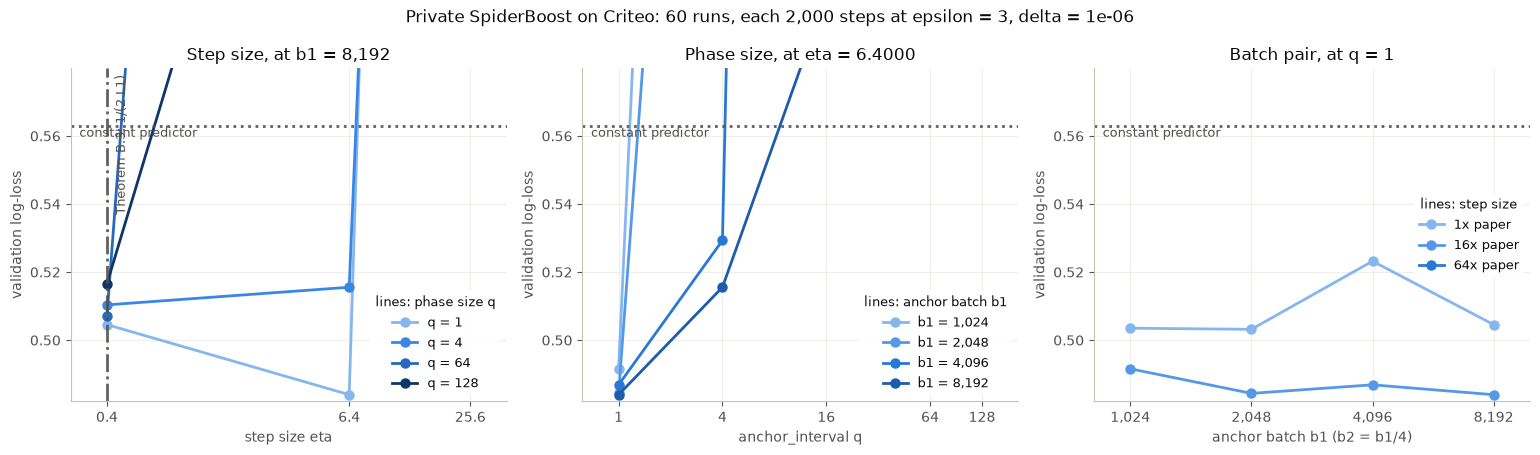

In [11]:
CONST_VAL_LOSS = log_loss(np.full_like(Y_VAL_NP, VAL_BASE_RATE), Y_VAL_NP)
BEST_LOSS = BEST_SCORES.loss

# Panel 1 groups by phase size, which carries more values than an
# ordinal ramp can separate by lightness. Four are drawn, spanning the
# axis end to end; the full axis is in the table above.
LINES_PER_PANEL = 4
last_index = len(ANCHOR_INTERVAL_GRID) - 1
spaced = [round(i * last_index / (LINES_PER_PANEL - 1))
          for i in range(LINES_PER_PANEL)]
PANEL_INTERVALS = tuple(dict.fromkeys(ANCHOR_INTERVAL_GRID[i] for i in spaced))

fig, (left, middle, right) = plt.subplots(1, 3, figsize=(15.5, 4.6))

for colour, interval in zip(RAMP_4, PANEL_INTERVALS):
    rows = [row for row in SWEEP
            if row.config.anchor_interval == interval
            and row.config.b1 == BEST_CONFIG.b1]
    rows.sort(key=lambda row: row.config.step_scale)
    left.plot([row.config.step_size for row in rows],
              [row.scores.loss for row in rows],
              marker="o", color=colour, label=f"q = {interval}")

for colour, (b1, b2) in zip(RAMP_5, BATCH_GRID):
    rows = [row for row in SWEEP if row.config.b1 == b1
            and row.config.step_scale == BEST_CONFIG.step_scale]
    rows.sort(key=lambda row: row.config.anchor_interval)
    middle.plot([row.config.anchor_interval for row in rows],
                [row.scores.loss for row in rows],
                marker="o", color=colour, label=f"b1 = {b1:,}")

for colour, scale in zip(RAMP_5, STEP_SCALE_GRID):
    rows = [row for row in SWEEP if row.config.step_scale == scale
            and row.config.anchor_interval == BEST_CONFIG.anchor_interval]
    rows.sort(key=lambda row: row.config.b1)
    right.plot([row.config.b1 for row in rows],
               [row.scores.loss for row in rows],
               marker="o", color=colour, label=f"{scale:g}x paper")

left.axvline(PAPER_STEP_SIZE, color=MUTED, linestyle="-.", alpha=0.9)
left.annotate("Theorem B.3: 1/(2 L1)", xy=(PAPER_STEP_SIZE, 0.98),
              xycoords=left.get_xaxis_transform(), xytext=(5, 0),
              textcoords="offset points", color=MUTED, fontsize=9,
              rotation=90, va="top")


class Panel(NamedTuple):
    """One panel of the sweep figure, and how its axis is labelled."""

    axis: object
    title: str
    xlabel: str
    legend_title: str
    ticks: list
    tick_label: object


def as_plain(value):
    return f"{value:g}"


def as_count(value):
    return f"{value:,}"


# A log axis left to itself labels its decades and crowds the minor ticks
# between them; these axes have five or eight points and those are what
# the reader wants a label on.
step_ticks = [scale * PAPER_STEP_SIZE for scale in STEP_SCALE_GRID]
interval_ticks = list(ANCHOR_INTERVAL_GRID)
batch_ticks = [b1 for b1, _ in BATCH_GRID]

PANELS = (
    Panel(left, f"Step size, at b1 = {BEST_CONFIG.b1:,}", "step size eta",
          "lines: phase size q", step_ticks, as_plain),
    Panel(middle, f"Phase size, at eta = {BEST_CONFIG.step_size:.4f}",
          "anchor_interval q", "lines: anchor batch b1",
          interval_ticks, as_plain),
    Panel(right, f"Batch pair, at q = {BEST_CONFIG.anchor_interval}",
          "anchor batch b1 (b2 = b1/4)", "lines: step size",
          batch_ticks, as_count),
)
for panel in PANELS:
    axis = panel.axis
    axis.axhline(CONST_VAL_LOSS, color=MUTED, linestyle=":", alpha=0.9)
    axis.text(0.02, CONST_VAL_LOSS, "constant predictor", color=MUTED,
              fontsize=9, va="top", transform=axis.get_yaxis_transform())
    axis.set_xscale("log")
    axis.set_xticks(panel.ticks)
    axis.set_xticklabels([panel.tick_label(tick) for tick in panel.ticks])
    axis.minorticks_off()
    axis.margins(x=0.10)
    axis.set_ylim(BEST_LOSS - 0.002, CONST_VAL_LOSS * 1.03)
    axis.set_xlabel(panel.xlabel)
    axis.set_ylabel("validation log-loss")
    axis.set_title(panel.title)
    # A solid surface-coloured patch behind the legend: these panels
    # carry reference lines that would otherwise run through the
    # entries. No edge, so it adds no ink of its own.
    axis.legend(title=panel.legend_title, fontsize=9, title_fontsize=9,
                frameon=True, facecolor="white", edgecolor="none",
                framealpha=0.95)
    axis.grid(alpha=0.5)

fig.suptitle(f"Private SpiderBoost on Criteo: {len(SWEEP)} runs, each "
             f"{STEPS:,} steps at epsilon = {TARGET_EPSILON:g}, "
             f"delta = {TARGET_DELTA}", color=INK)
fig.tight_layout()
plt.show()

In [12]:
def loss_at(rows, coordinates):
    """The one grid row at these coordinates, or nan if there is none."""
    for row in rows:
        if all(getattr(row.config, field) == value
               for field, value in coordinates.items()):
            return row.scores.loss
    return float("nan")


def show_matrix(rows, row_axis, column_axis, held_axis, config):
    """The validation log-loss behind one panel of the figure.

    One row per line the panel draws, one column per point on its
    horizontal, with the third axis pinned where the panel pinned it.
    """
    held_value = getattr(config, held_axis.field)
    print(f"validation log-loss: {row_axis.short} down, "
          f"{column_axis.short} across, at {held_axis.short} = "
          f"{held_value:g}")
    header = "".join(f"{value:>9g}" for value in column_axis.values)
    print(f"  {row_axis.short:>8}{header}")
    for row_value in row_axis.values:
        cells = []
        for column_value in column_axis.values:
            coordinates = {row_axis.field: row_value,
                           column_axis.field: column_value,
                           held_axis.field: held_value}
            cells.append(f"{loss_at(rows, coordinates):>9.4f}")
        body = "".join(cells)
        print(f"  {row_value:>8g}{body}")
    print()


show_matrix(SWEEP, PHASE_AXIS, STEP_AXIS, BATCH_AXIS, BEST_CONFIG)
show_matrix(SWEEP, BATCH_AXIS, PHASE_AXIS, STEP_AXIS, BEST_CONFIG)
show_matrix(SWEEP, STEP_AXIS, BATCH_AXIS, PHASE_AXIS, BEST_CONFIG)
print(f"the selected configuration is q = {BEST_CONFIG.anchor_interval}, "
      f"b1 = {BEST_CONFIG.b1}, {BEST_CONFIG.step_scale:g}x the paper's step "
      f"size, at validation log-loss {BEST_SCORES.loss:.4f}.")

validation log-loss: q down, x paper across, at b1 = 8192
         q        1       16       64
         1   0.5046   0.4840   1.6326
         4   0.5104   0.5156   1.3625
        16   0.5031   0.6012   5.3422
        64   0.5071   1.4576   9.8959
       128   0.5166   0.7533  11.4072

validation log-loss: b1 down, q across, at x paper = 16
        b1        1        4       16       64      128
      1024   0.4916   1.1531   7.9546  10.6567  11.6891
      2048   0.4844   0.8980   4.3222   9.8760   9.8051
      4096   0.4869   0.5293   1.9028   5.1311  10.9059
      8192   0.4840   0.5156   0.6012   1.4576   0.7533

validation log-loss: x paper down, b1 across, at q = 1
   x paper     1024     2048     4096     8192
         1   0.5035   0.5032   0.5232   0.5046
        16   0.4916   0.4844   0.4869   0.4840
        64   0.6939   0.7281   3.5296   1.6326

the selected configuration is q = 1, b1 = 8192, 16x the paper's step size, at validation log-loss 0.4840.


### Reading the three axes

**The phase size is the one axis that moves anything, and it wants `q = 1`.**
Validation log-loss goes `0.4840 → 0.5156 → 0.6012 → 1.4576` as `q` runs
1 → 4 → 16 → 64, and the selected value is the degenerate end of the axis —
the setting at which Algorithm 2 is unclipped noisy SGD and not SpiderBoost at
all. Against the wider seed spread of `0.0467` the steps out to `q = 16` and
beyond are resolved several times over; the first step, `q = 1 → 4` at
`0.0316`, is **not** resolved even against the narrower `0.0358`.

**The batch axis is flat and does not rescue the phase size.** End to end it
spans `0.0076` — `0.4916, 0.4844, 0.4869, 0.4840` — which is a fifth of the
narrower spread and not monotone besides. Nothing here is resolved, and the
axis should be read as "no effect this file can see" rather than as a gentle
trend.

**Those two facts together are the finding, and they are the dense execution's
finding inverted.** That execution reported the phase size and the anchor batch
as a single axis: a phase reuses one anchor estimate for `q - 1` variation
steps, that estimate's noise goes like `mu·L0/b1`, so a bigger anchor buys a
longer affordable phase. It measured `+0.0337` from `q = 1` to `q = 128` at
`b1 = 1,024` and `+0.0006` at `b1 = 16,384` — the phase size was nearly free
once the anchor was good enough.

Here the anchor never gets good enough. At every batch pair on this grid the
sweep's best row is `q = 1`, and the batch axis is flat rather than climbing,
so there is no trend pointing at relief further up it. `b1 = 16,384` is the
point that would test this and it does not fit in memory — but a flat axis is
weak evidence that the missing point would not have changed the answer, which
is worth stating precisely because the truncation was not a choice. It is an
extrapolation off four points and it is not a measurement.

### The step size, and what Theorem B.3's value costs

**Theorem B.3's `1/(2·L1) = 0.4` is not what the sweep selects**, and the
matched contrast at the selected phase size and batch pair puts the paper's
value `0.0206` of validation log-loss behind `16x`. That gap is **under both
seed spreads**, so this file does not establish that `16x` is better than the
paper's value — it establishes only that the selection landed there.

**What is resolved is the far end.** `64x` scores `1.6326` against `16x`'s
`0.4840`, a collapse of `1.1486` that no spread here comes near. The axis
therefore has a usable interior and a cliff, and the paper's value and the
selected value sit together inside the interior, indistinguishable at this
sample size.

That is a weaker statement than the dense execution's and it is weaker for a
measurable reason: the run-to-run spread on this encoding is `0.0358` where
that execution measured `0.0007` at its selected configuration. The step-size
axis has not changed shape. The instrument reading it has got coarser.

In [13]:
# The matched contrast, and the one this notebook headlines: the same
# phase size and the same batch pair as the winner, moved one point along
# the step-size axis and nothing else. A gap read off two configurations
# that differ on more than the axis under test is not a reading of that
# axis.
step_rows = profile(SWEEP, STEP_AXIS, BEST_CONFIG)
matched_paper = next(row for row in step_rows
                     if row.config.step_scale == 1.0)

# And, separately, the lowest-loss 1x row anywhere in the grid, which is a
# different shape and is reported as one.
paper_rows = [row for row in finite(SWEEP) if row.config.step_scale == 1.0]
BEST_PAPER = min(paper_rows, key=lambda row: row.scores.loss)

print(f"Theorem B.3's step size at R = {FEATURE_NORM_BOUND} with a bias: "
      f"eta = {PAPER_STEP_SIZE:.6f}")
print()
if BEST_CONFIG.step_scale == 1.0:
    print("The selection landed on it. The reported model therefore keeps "
          "the convergence guarantee as well as the privacy, and there is "
          "nothing to trade off.")
else:
    matched_scores = matched_paper.scores
    loss_gap = matched_scores.loss - BEST_SCORES.loss
    pr_gap = matched_scores.pr_auc - BEST_SCORES.pr_auc
    print("The selection did NOT land on it. The matched contrast, at the "
          "selected phase size and batch pair:")
    print(f"  q = {BEST_CONFIG.anchor_interval}, b1 = {BEST_CONFIG.b1}, "
          f"b2 = {BEST_CONFIG.b2}")
    print(f"    selected  {BEST_CONFIG.step_scale:>4g}x  "
          f"eta = {BEST_CONFIG.step_size:>8.4f}   val log-loss "
          f"{BEST_SCORES.loss:.4f}   PR-AUC {BEST_SCORES.pr_auc:.4f}")
    print(f"    paper's   {matched_paper.config.step_scale:>4g}x  "
          f"eta = {matched_paper.config.step_size:>8.4f}   val log-loss "
          f"{matched_scores.loss:.4f}   PR-AUC {matched_scores.pr_auc:.4f}")
    print(f"    the paper's value costs {loss_gap:+.4f} validation log-loss "
          f"and {pr_gap:+.4f} PR-AUC, at the same epsilon, on the "
          f"output-rule iterate.")
    print()
    print("Separately, the lowest-loss 1x row anywhere in the grid — a "
          "different shape, so not a reading of the step-size axis:")
    print(f"    q = {BEST_PAPER.config.anchor_interval}, "
          f"b1 = {BEST_PAPER.config.b1}, b2 = {BEST_PAPER.config.b2}, "
          f"val log-loss {BEST_PAPER.scores.loss:.4f}, "
          f"PR-AUC {BEST_PAPER.scores.pr_auc:.4f}")
    if BEST_PAPER.config.anchor_interval == 1:
        print("    that row sits at q = 1, which is the degenerate end of "
              "the phase-size axis: unclipped noisy SGD, not Algorithm 2.")

print()
print("the step-size axis at the selected q and batch pair, in full:")
for row in step_rows:
    tags = []
    if row.config.step_scale == 1.0:
        tags.append("Theorem B.3")
    if row.config == BEST_CONFIG:
        tags.append("selected")
    tag = ("   <- " + ", ".join(tags)) if tags else ""
    print(f"  {row.config.step_scale:>6g}x  eta = {row.config.step_size:>9.4f}"
          f"   val log-loss {row.scores.loss:>9.4f}   "
          f"PR-AUC {row.scores.pr_auc:.4f}{tag}")

Theorem B.3's step size at R = 2.0 with a bias: eta = 0.400000

The selection did NOT land on it. The matched contrast, at the selected phase size and batch pair:
  q = 1, b1 = 8192, b2 = 2048
    selected    16x  eta =   6.4000   val log-loss 0.4840   PR-AUC 0.5140
    paper's      1x  eta =   0.4000   val log-loss 0.5046   PR-AUC 0.4730
    the paper's value costs +0.0206 validation log-loss and -0.0411 PR-AUC, at the same epsilon, on the output-rule iterate.

Separately, the lowest-loss 1x row anywhere in the grid — a different shape, so not a reading of the step-size axis:
    q = 16, b1 = 8192, b2 = 2048, val log-loss 0.5031, PR-AUC 0.4759

the step-size axis at the selected q and batch pair, in full:
       1x  eta =    0.4000   val log-loss    0.5046   PR-AUC 0.4730   <- Theorem B.3
      16x  eta =    6.4000   val log-loss    0.4840   PR-AUC 0.5140   <- selected
      64x  eta =   25.6000   val log-loss    1.6326   PR-AUC 0.5009


## 5. How much of that is the seed?

The grid runs each configuration once, at a seed folded off its position, so
every gap in section 4 carries one draw of the sampling stream, one draw of the
noise stream **and one draw of the output rule** — Algorithm 2 returns a
uniformly chosen iterate, which is run-to-run variance a last-iterate method
does not have. A gap smaller than that variance is not a finding.

So two configurations are re-run at five seeds each: the selected one, and the
lowest-loss row in the grid at Theorem B.3's step size. The pair is deliberate:
**the point is not a single noise floor but how much the noise floor moves
across the grid.** The initialization does not move; the sampling stream, the
noise stream and the output-rule draw do.

**This is the one place the grid was not economised on, and the reason is
what it measures.** Everything else in this file was cut to fit the wall
clock — five phase sizes of eight, four batch pairs of five, three step sizes
of five — but on this encoding the seed spread comes out wider than most of
the grid it is there to judge, so a thin estimate of it would put every other
number in the file on sand. It is reported as min/max, it is a spread rather
than a confidence interval, and where a grid movement is close to it the
closing says the movement is unresolved rather than picking a side.

The same cell shows the selected configuration's **last iterate** beside its
output-rule iterate, once. No bound covers the last iterate — no gradient
estimate was ever taken at it — and nothing in this notebook reports it.

In [14]:
def repeats_of(config, label):
    """Re-runs of one configuration, differing only in their streams."""
    # The same seed list for both configurations, so the two spreads are
    # paired rather than two independent draws.
    jobs = [config._replace(seed_index=REPEAT_SEED_BASE + seed)
            for seed in SEEDS]
    with ThreadPoolExecutor(max_workers=workers_for(config.b1)) as pool:
        rows = list(pool.map(run_and_score, jobs))
    losses = [row.scores.loss for row in rows]
    pr_aucs = [row.scores.pr_auc for row in rows]
    print(f"{label}")
    print(f"  val log-loss  mean {np.mean(losses):.4f}  "
          f"[{min(losses):.4f}, {max(losses):.4f}]  "
          f"spread {max(losses) - min(losses):.4f}")
    print(f"  val PR-AUC    mean {np.mean(pr_aucs):.4f}  "
          f"[{min(pr_aucs):.4f}, {max(pr_aucs):.4f}]  "
          f"spread {max(pr_aucs) - min(pr_aucs):.4f}")
    return rows


selected_label = (
    f"the selected configuration: q = {BEST_CONFIG.anchor_interval}, "
    f"b1 = {BEST_CONFIG.b1}, b2 = {BEST_CONFIG.b2}, "
    f"eta = {BEST_CONFIG.step_size:.4f} ({BEST_CONFIG.step_scale:g}x paper)")
paper_config = BEST_PAPER.config
degenerate = " -- the degenerate q = 1 end" if paper_config.anchor_interval == 1 else ""
paper_label = (
    f"the best 1x row in the grid{degenerate}: "
    f"q = {paper_config.anchor_interval}, b1 = {paper_config.b1}, "
    f"b2 = {paper_config.b2}, eta = {paper_config.step_size:.4f}")

t0 = time.time()
SELECTED_REPEATS = repeats_of(BEST_CONFIG, selected_label)
print()
PAPER_REPEATS = repeats_of(paper_config, paper_label)

def spread_of(rows):
    losses = [row.scores.loss for row in rows]
    return max(losses) - min(losses)


SELECTED_SPREAD = spread_of(SELECTED_REPEATS)
PAPER_SPREAD = spread_of(PAPER_REPEATS)
print()
SPREAD_RATIO = (max(SELECTED_SPREAD, PAPER_SPREAD)
                / min(SELECTED_SPREAD, PAPER_SPREAD))
print(f"the two log-loss spreads over {len(SEEDS)} seeds: "
      f"{SELECTED_SPREAD:.4f} at the selected configuration, "
      f"{PAPER_SPREAD:.4f} at the other one -- a factor of "
      f"{SPREAD_RATIO:.1f} between them.")
print("They differ, so there is no single noise "
      "floor for this grid. A difference in section 4 is read against the "
      "spread measured nearest to it, and where that is, is stated with "
      "the difference; a difference under the WIDER of the two is not "
      "resolved anywhere in this file.")
print(f"\n({time.time() - t0:.0f}s)")

W0823 23:40:42.451489 2233761 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:40:42.930669 2233761 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:42:25.789237 2233761 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:42:26.239914 2233761 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:44:08.935587 2233761 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


...

W0823 23:52:35.045995 2234592 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:52:36.935725 2234592 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:53:40.713444 2234592 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:53:42.610848 2234592 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


the best 1x row in the grid: q = 16, b1 = 8192, b2 = 2048, eta = 0.4000
  val log-loss  mean 0.5283  [0.5027, 0.5494]  spread 0.0467
  val PR-AUC    mean 0.4305  [0.3931, 0.4761]  spread 0.0829

the two log-loss spreads over 5 seeds: 0.0358 at the selected configuration, 0.0467 at the other one -- a factor of 1.3 between them.
They differ, so there is no single noise floor for this grid. A difference in section 4 is read against the spread measured nearest to it, and where that is, is stated with the difference; a difference under the WIDER of the two is not resolved anywhere in this file.

(844s)


In [15]:
output_params, last_params = fit(BEST_CONFIG)
OUTPUT_RULE_SCORES = evaluate_at(output_params, X_VAL, Y_VAL_NP)
LAST_ITERATE_SCORES = evaluate_at(last_params, X_VAL, Y_VAL_NP)
REPORTED_PARAMS = output_params

print("the selected configuration's two iterates, on validation:")
print(f"  {'':<36}{'log-loss':>10}{'PR-AUC':>9}{'ECE':>9}")
print(f"  {'output rule (w-bar, reported)':<36}"
      f"{OUTPUT_RULE_SCORES.loss:10.4f}{OUTPUT_RULE_SCORES.pr_auc:9.4f}"
      f"{OUTPUT_RULE_SCORES.ece:9.4f}")
print(f"  {'last iterate (no bound covers it)':<36}"
      f"{LAST_ITERATE_SCORES.loss:10.4f}{LAST_ITERATE_SCORES.pr_auc:9.4f}"
      f"{LAST_ITERATE_SCORES.ece:9.4f}")
print(f"\n  gap (last - output rule): log-loss "
      f"{LAST_ITERATE_SCORES.loss - OUTPUT_RULE_SCORES.loss:+.4f}, PR-AUC "
      f"{LAST_ITERATE_SCORES.pr_auc - OUTPUT_RULE_SCORES.pr_auc:+.4f}")
print("\nEverything below reports the output-rule iterate.")

W0823 23:54:46.380430 2225406 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:54:46.848038 2225406 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


the selected configuration's two iterates, on validation:
                                        log-loss   PR-AUC      ECE
  output rule (w-bar, reported)           0.4840   0.5140   0.0146
  last iterate (no bound covers it)       0.4789   0.5249   0.0154

  gap (last - output rule): log-loss -0.0051, PR-AUC +0.0109

Everything below reports the output-rule iterate.


## 6. The selected configuration over training steps

Hold the phase size, the batch pair and the step size at the values section 4
picked, and vary only how long the run trains. **Each point is an independent
run** at its own recalibrated noise scales — the private loop returns no
optimizer state, no estimator state and no phase position, precisely so that a
run cannot be resumed and replay its noise stream, so a chunked curve would be
a different mechanism rather than the same run observed more often.

Because each point is recalibrated over exactly the steps it runs, **every
point on this curve spends the same ε = 3**: a longer run here is not a more
expensive run, it is the same budget spread over more, noisier releases. That is
the question this section exists to answer, and the reason the trajectory runs
past the sweep's 2,000 steps all the way to 10,000, the count the DP-SGD sweep
and the SpiderBoost-vs-DP-SGD comparison both use: it measures what the
wall-clock cap cost.

In [16]:
for steps in TRAJECTORY_STEPS:
    calibrate(steps, BEST_CONFIG.anchor_interval, BEST_CONFIG.b1,
              BEST_CONFIG.b2)

def trajectory_job(index, steps):
    config = BEST_CONFIG._replace(seed_index=TRAJECTORY_SEED_BASE + index)
    return TrajectoryJob(steps=steps, config=config)


def run_trajectory_point(job):
    return run_and_score(job.config, steps=job.steps)


trajectory_jobs = [trajectory_job(index, steps)
                   for index, steps in enumerate(TRAJECTORY_STEPS)]

t0 = time.time()
with ThreadPoolExecutor(max_workers=workers_for(BEST_CONFIG.b1)) as pool:
    TRAJECTORY = list(pool.map(run_trajectory_point, trajectory_jobs))
TRAJECTORY_SECONDS = time.time() - t0

print(f"q = {BEST_CONFIG.anchor_interval}, b1 = {BEST_CONFIG.b1}, "
      f"b2 = {BEST_CONFIG.b2}, eta = {BEST_CONFIG.step_size:.4f}, "
      f"one independent run per row, each at epsilon = {TARGET_EPSILON:g}")
print(f"  {'steps':>7} {'sigma_1':>12} {'sigma_2':>12} {'epsilon':>9} "
      f"{'val log-loss':>13} {'val PR-AUC':>11} {'val ECE':>9}")
for steps, row in zip(TRAJECTORY_STEPS, TRAJECTORY):
    shape = (steps, BEST_CONFIG.anchor_interval, BEST_CONFIG.b1,
             BEST_CONFIG.b2)
    scales, spent = SCALES[shape], EPSILON_BACK[shape]
    mark = "  <- the sweep's step count" if steps == STEPS else ""
    print(f"  {steps:>7,} {scales.anchor_noise_scale:>12.4e} "
          f"{scales.variation_noise_rate:>12.4e} {spent:>9.6f} "
          f"{row.scores.loss:>13.4f} {row.scores.pr_auc:>11.4f} "
          f"{row.scores.ece:>9.4f}{mark}")
print(f"\n{len(TRAJECTORY)} independent runs in {TRAJECTORY_SECONDS:.0f}s; "
      f"every row is the output-rule iterate.")

W0823 23:56:31.373169 2235634 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:56:31.853464 2235634 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:56:38.690490 2235634 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:56:39.169537 2235634 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:56:52.381422 2235634 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


...

W0823 23:59:54.299596 2235634 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0823 23:59:54.777313 2235634 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0824 00:03:19.767139 2235634 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


W0824 00:03:20.255504 2235634 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951551502 bytes) by rematerialization; only reduced to 36.67GiB (39373726912 bytes), down from 36.67GiB (39373726920 bytes) originally


q = 1, b1 = 8192, b2 = 2048, eta = 6.4000, one independent run per row, each at epsilon = 3
    steps      sigma_1      sigma_2   epsilon  val log-loss  val PR-AUC   val ECE
      125   2.1773e-04   4.8686e-04  3.000000        0.5678      0.4223    0.1052
      250   2.2772e-04   5.0920e-04  3.000000        0.5502      0.4292    0.1042
      500   2.4217e-04   5.4150e-04  2.999992        0.4923      0.4958    0.0180
    1,000   2.6572e-04   5.9417e-04  2.999993        0.4845      0.5137    0.0180
    2,000   3.1031e-04   6.9388e-04  2.999995        0.4960      0.4877    0.0192  <- the sweep's step count
    4,000   3.8953e-04   8.7101e-04  2.999997        0.4783      0.5257    0.0098
   10,000   5.6388e-04   1.2609e-03  2.999998        0.4756      0.5312    0.0094

7 independent runs in 921s; every row is the output-rule iterate.


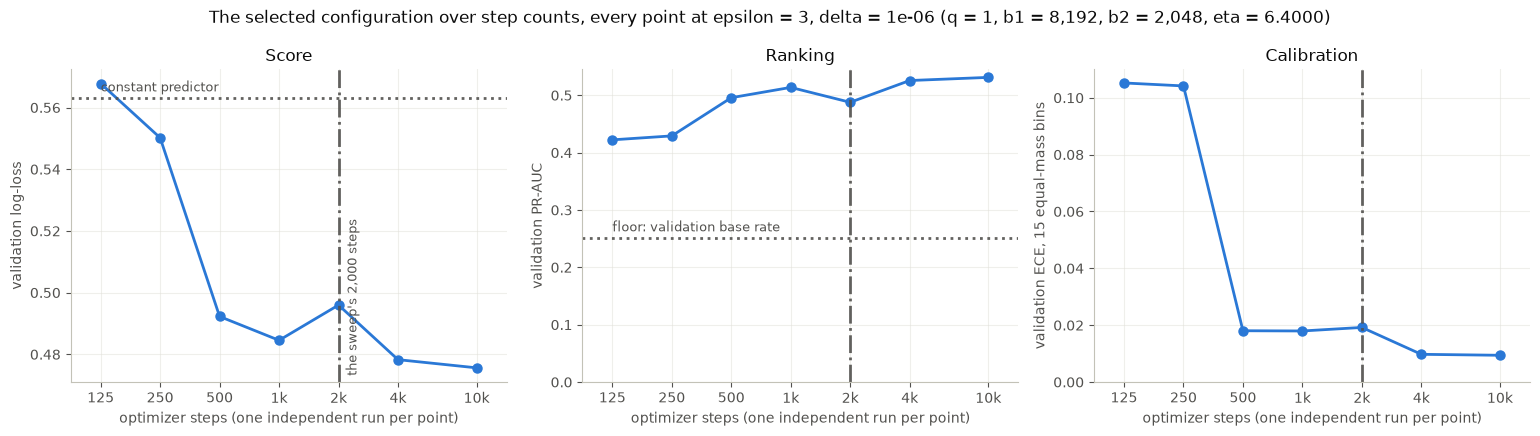

In [17]:
steps_axis = list(TRAJECTORY_STEPS)
loss_axis = [row.scores.loss for row in TRAJECTORY]
pr_axis = [row.scores.pr_auc for row in TRAJECTORY]
ece_axis = [row.scores.ece for row in TRAJECTORY]

fig, (left, middle, right) = plt.subplots(1, 3, figsize=(15.5, 4.4))

left.plot(steps_axis, loss_axis, marker="o", color=ACCENT)
left.axhline(CONST_VAL_LOSS, color=MUTED, linestyle=":", alpha=0.9)
left.annotate("constant predictor", xy=(steps_axis[0], CONST_VAL_LOSS),
              xytext=(0, 5), textcoords="offset points", color=MUTED,
              fontsize=9)
left.set_ylabel("validation log-loss")
left.set_title("Score")

middle.plot(steps_axis, pr_axis, marker="o", color=ACCENT)
middle.axhline(VAL_BASE_RATE, color=MUTED, linestyle=":", alpha=0.9)
middle.annotate("floor: validation base rate",
                xy=(steps_axis[0], VAL_BASE_RATE), xytext=(0, 5),
                textcoords="offset points", color=MUTED, fontsize=9)
middle.set_ylabel("validation PR-AUC")
middle.set_ylim(bottom=0.0)
middle.set_title("Ranking")

# ECE is an upward-biased estimate, so the distance from zero is not a
# calibration error; only the movement across this panel is readable, and
# every point is the same bin count on the same evaluation set.
right.plot(steps_axis, ece_axis, marker="o", color=ACCENT)
right.set_ylabel(f"validation ECE, {N_BINS} equal-mass bins")
right.set_ylim(bottom=0.0)
right.set_title("Calibration")

def as_steps(value):
    return f"{value // 1000:g}k" if value >= 1000 else f"{value:g}"


for axis in (left, middle, right):
    axis.axvline(STEPS, color=MUTED, linestyle="-.", alpha=0.9)
    axis.set_xlabel("optimizer steps (one independent run per point)")
    axis.set_xscale("log")
    axis.set_xticks(steps_axis)
    axis.set_xticklabels([as_steps(steps) for steps in steps_axis])
    axis.minorticks_off()
    axis.margins(x=0.08)
    axis.grid(alpha=0.5)
left.annotate(f"the sweep's {STEPS:,} steps", xy=(STEPS, 0.02),
              xycoords=left.get_xaxis_transform(), xytext=(5, 0),
              textcoords="offset points", color=MUTED, fontsize=9,
              rotation=90, va="bottom")

fig.suptitle(f"The selected configuration over step counts, every point at "
             f"epsilon = {TARGET_EPSILON:g}, delta = {TARGET_DELTA} "
             f"(q = {BEST_CONFIG.anchor_interval}, b1 = {BEST_CONFIG.b1:,}, "
             f"b2 = {BEST_CONFIG.b2:,}, eta = "
             f"{BEST_CONFIG.step_size:.4f})", color=INK)
fig.tight_layout()
plt.show()

### What the 2,000-step cap cost

**Nothing this file can resolve.** The trajectory runs the selected
configuration from 125 steps to 10,000, every point recalibrated so it spends
the same ε = 3, and validation log-loss goes
`0.5678, 0.5502, 0.4923, 0.4845, 0.4960, 0.4783, 0.4756`. The move from the
sweep's 2,000 steps out to 10,000 is `0.0204`, well under the `0.0358` spread
measured at this very configuration.

**The curve's own middle makes the point better than any argument.** The
1,000-step row scores `0.4845` and the 2,000-step row `0.4960` — a longer run
scoring worse, at the same budget, which is a thing only noise does. And the
2,000-step row here is the *same configuration* the sweep ran, on a different
stream: the sweep got `0.4840` and this got `0.4960`, a gap of `0.0120` from
the seed alone.

What *is* resolved is the short end: 125 and 250 steps score `0.5678` and
`0.5502`, which are worse than everything past 500 by more than either spread.
Under about 500 steps the budget is spread over too few releases to find
anything. Above it, this file cannot tell 500 from 10,000.

## 7. The operating point, then the test split

A confusion matrix is a quantity at a threshold, and a threshold is a choice.
It is made here by one rule, on validation, and frozen before the test split is
read: **the threshold that maximises F1 on the validation split**
(`best_f1_threshold`, which takes every observed score as a candidate and so
finds the exact maximiser rather than approximating it). Choosing it on test
would make every number after it a fitted quantity. Which split a threshold was
chosen on is the caller's to state, and this paragraph is that statement
(ADR-0016).

The model reported below is the **output-rule iterate of a single run** of the
selected configuration at 2,000 steps — the run in section 5, on the sweep's own
stream for that configuration. Its ε is the one section 2 calibrated and section
2 reported back.

In [18]:
val_probs = probabilities(REPORTED_PARAMS, X_VAL)
val_point = best_f1_threshold(val_probs, Y_VAL_NP)
THRESHOLD = val_point.threshold

print(f"validation-optimal threshold p >= {THRESHOLD:.4f}   "
      f"val F1 = {val_point.f1:.4f}")
print("chosen on validation, frozen here, before the test split is read.")

validation-optimal threshold p >= 0.2445   val F1 = 0.5230
chosen on validation, frozen here, before the test split is read.


In [19]:
# The first read of the test split in this notebook.
Y_TEST_NP = np.asarray(Y_TEST, dtype=np.float64)
TEST_BASE_RATE = float(Y_TEST_NP.mean())
test_probs = probabilities(REPORTED_PARAMS, X_TEST)
TEST_CURVE = pr_curve(test_probs, Y_TEST_NP)
TEST_CONFUSION = confusion_at(test_probs, Y_TEST_NP, THRESHOLD)

test_loss = log_loss(test_probs, Y_TEST_NP)
test_ece = expected_calibration_error(test_probs, Y_TEST_NP, n_bins=N_BINS)
TEST_SCORES = Eval(loss=test_loss, pr_auc=TEST_CURVE.average_precision,
                   ece=test_ece)
TEST_NE = normalized_entropy(test_probs, Y_TEST_NP)
TEST_CAL_RATIO = calibration_ratio(test_probs, Y_TEST_NP)

const_probs = np.full_like(Y_TEST_NP, TEST_BASE_RATE)
const_loss = log_loss(const_probs, Y_TEST_NP)
const_ne = normalized_entropy(const_probs, Y_TEST_NP)
const_ece = expected_calibration_error(const_probs, Y_TEST_NP, n_bins=N_BINS)
const_cal_ratio = calibration_ratio(const_probs, Y_TEST_NP)
print(f"test split: {len(Y_TEST_NP):,} rows, base rate "
      f"{TEST_BASE_RATE:.4f} (the PR-AUC floor)\n")
print(f"{'':<34}{'log-loss':>10}{'NE':>8}{'ECE':>8}{'cal-ratio':>11}"
      f"{'PR-AUC':>9}")
print(f"{'constant predictor':<34}{const_loss:10.4f}{const_ne:8.4f}"
      f"{const_ece:8.4f}{const_cal_ratio:11.4f}{TEST_BASE_RATE:9.4f}")
print(f"{'Private SpiderBoost (w-bar)':<34}{TEST_SCORES.loss:10.4f}"
      f"{TEST_NE:8.4f}{TEST_SCORES.ece:8.4f}{TEST_CAL_RATIO:11.4f}"
      f"{TEST_SCORES.pr_auc:9.4f}")
print()
print(f"one run, {STEPS:,} steps, output-rule iterate, at "
      f"q = {BEST_CONFIG.anchor_interval}, b1 = {BEST_CONFIG.b1}, "
      f"b2 = {BEST_CONFIG.b2}, eta = {BEST_CONFIG.step_size:.4f}, "
      f"epsilon = {TARGET_EPSILON:g}, delta = {TARGET_DELTA}, "
      f"{ACCOUNTANT.upper()} accounting.")

test split: 200,000 rows, base rate 0.2520 (the PR-AUC floor)

                                    log-loss      NE     ECE  cal-ratio   PR-AUC
constant predictor                    0.5645  1.0000  0.0000     1.0000   0.2520
Private SpiderBoost (w-bar)           0.4868  0.8624  0.0157     1.0525   0.5105

one run, 2,000 steps, output-rule iterate, at q = 1, b1 = 8192, b2 = 2048, eta = 6.4000, epsilon = 3, delta = 1e-06, RDP accounting.


In [20]:
def show_confusion(confusion, title, threshold):
    """The 2x2 as a table — four numbers do not need a chart.

    Every count is read by name: the four are transposed by accident when
    they are unpacked in a row.
    """
    caught = confusion.true_positives
    missed = confusion.false_negatives
    flagged_wrongly = confusion.false_positives
    left_alone = confusion.true_negatives
    predicted_positive = caught + flagged_wrongly
    actual_positive = caught + missed
    precision = caught / predicted_positive if predicted_positive else float("nan")
    recall = caught / actual_positive if actual_positive else float("nan")
    print(title)
    print(f"                 predicted no    predicted click")
    print(f"  actual no      {left_alone:>12,}    {flagged_wrongly:>15,}")
    print(f"  actual click   {missed:>12,}    {caught:>15,}")
    print(f"  precision {precision:.4f}   recall (TPR) {recall:.4f}   "
          f"F1 {2 * precision * recall / (precision + recall):.4f}   "
          f"(at threshold p >= {threshold:.4f})")
    return precision, recall


confusion_title = (
    f"Private SpiderBoost on the test split, output-rule iterate, "
    f"epsilon = {TARGET_EPSILON:g}")
TEST_PRECISION, TEST_RECALL = show_confusion(TEST_CONFUSION, confusion_title,
                                             THRESHOLD)

Private SpiderBoost on the test split, output-rule iterate, epsilon = 3
                 predicted no    predicted click
  actual no           103,521             46,079
  actual click         16,326             34,074
  precision 0.4251   recall (TPR) 0.6761   F1 0.5220   (at threshold p >= 0.2445)


The precision–recall curve, with PR-AUC in the title, the base rate as the floor
a random ranking reaches, and the chosen operating point marked. The curve is
the model's behaviour at every threshold; the marker is the one point the
confusion matrix above reports.

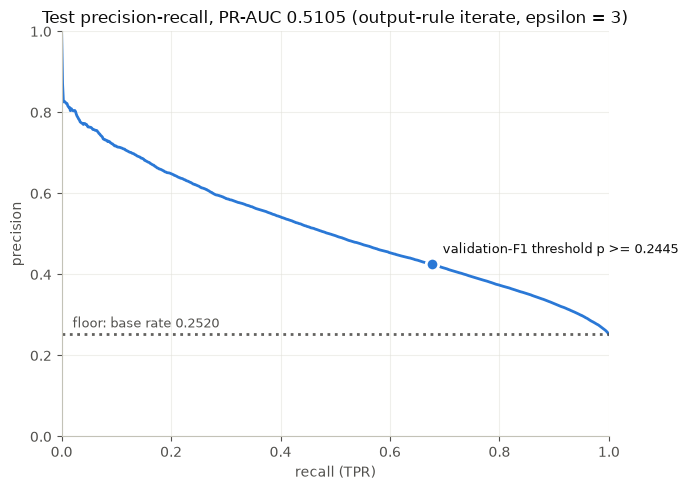

In [21]:
fig, axis = plt.subplots(figsize=(7, 5))

stride = max(1, len(TEST_CURVE.recall) // 2000)
axis.plot(TEST_CURVE.recall[::stride], TEST_CURVE.precision[::stride],
          color=ACCENT)
axis.plot([TEST_RECALL], [TEST_PRECISION], marker="o", markersize=9,
          color=ACCENT, linestyle="none", markeredgecolor="white",
          markeredgewidth=2)
axis.annotate(f"validation-F1 threshold p >= {THRESHOLD:.4f}",
              xy=(TEST_RECALL, TEST_PRECISION), xytext=(8, 8),
              textcoords="offset points", color=INK, fontsize=9)

axis.axhline(TEST_BASE_RATE, color=MUTED, linestyle=":", alpha=0.9)
axis.annotate(f"floor: base rate {TEST_BASE_RATE:.4f}",
              xy=(0.02, TEST_BASE_RATE), xytext=(0, 5),
              textcoords="offset points", color=MUTED, fontsize=9)
axis.set_xlabel("recall (TPR)")
axis.set_ylabel("precision")
axis.set_xlim(0, 1)
axis.set_ylim(0, 1)
axis.set_title(f"Test precision-recall, PR-AUC {TEST_SCORES.pr_auc:.4f} "
               f"(output-rule iterate, epsilon = {TARGET_EPSILON:g})")
axis.grid(alpha=0.5)
fig.tight_layout()
plt.show()

## What this shows, and what it does not

**At ε = 3, δ = 1e-6 by RDP, on 700,000 one-hot Criteo rows at `R = 2.0`, the
configuration this sweep selects is phase size `q = 1`, anchor batch
`b1 = 8,192`, variation batch `b2 = 2,048`, and a step size of `6.4` — sixteen
times Theorem B.3's `1/(2·L1) = 0.4`.** Its output-rule iterate — Algorithm 2's
`w̄`, drawn uniformly from the iterates at which a gradient estimate was
released — reaches test log-loss `0.4868` against the constant predictor's
`0.5645`, normalized entropy `0.8624`, PR-AUC `0.5105` against a base-rate
floor of `0.2520`, ECE `0.0157` and calibration ratio `1.0525`. At the
validation-F1 threshold `p >= 0.2445`, frozen before the test split was read,
it catches `34,074` of the `50,400` test clicks and raises `46,079` false
alarms: precision `0.4251`, recall `0.6761`, F1 `0.5220`.

**The selected configuration is `q = 1`, which is to say the sweep selected
its way out of the algorithm.** At `q = 1` every step is an anchor step, there
are no variation steps, and Algorithm 2 reduces to unclipped noisy SGD. That is
a legitimate point on the axis and the grid was built to include it, but a
tuning notebook for SpiderBoost reporting that SpiderBoost's distinguishing
parameter should be switched off is the headline, not a footnote.

**What this sweep ranks vastly exceeds what it resolves, and the gap is wider
than the dense execution's.** The two five-seed spreads are `0.0358` at the
selected configuration and `0.0467` at the other, against `0.0007` and `0.0074`
on the frequency encoding. Measured against them, **three of the four movements
this grid contains are not resolved at all**: the batch axis end to end
(`0.0076`), the step size from Theorem B.3's value to the selected `16x`
(`0.0206`), and even the first step of the phase-size axis, `q = 1 → 4`
(`0.0316`). What is resolved is the coarse structure — phase sizes of 16 and
above are ruinous, and `64x` the paper's step size collapses the run — and
nothing finer.

**So the selected configuration is a selection and not a demonstration.** Three
other rows sit within the seed spread of it. Reporting it as *the* tuned
configuration would overstate what 60 runs at this noise level can support, and
the honest summary is that this encoding makes SpiderBoost's own knobs hard to
tune at this budget rather than that these are the right settings.

**Why the instrument got coarser is not a mystery.** SpiderBoost perturbs every
coordinate at every release and there are 551,947 of them here against 40, so
at a fixed per-coordinate scale the displacement is far longer, and the output
rule adds a uniform draw over released iterates on top. The encoding
comparison finds the same asymmetry from the other side: DP-SGD on this
encoding pays real utility for its noise where the dense encodings pay
essentially none.

Not shown, and not claimed:

- **The grid is 60 runs, not the dense execution's 200**, and the batch axis
  stops at `b1 = 8,192` because `16,384` does not fit in memory — which is the
  pair that execution selected. Section 3 names every dropped point. The
  reading above argues from a flat batch axis that the missing point would
  probably not have changed the answer; that is an extrapolation off four
  points, not a measurement, and it is the one place this file leans on
  something it did not run.
- **This does not transfer to the SpiderBoost-vs-DP-SGD comparison.** That file
  is dense and is not being moved, so a configuration selected here is selected
  on a different feature space. The two share a protocol and a test split, not
  a representation.
- **One initialization, and the seed varies with the configuration.** Every run
  starts from the same parameters, but each grid point's sampling and noise
  streams are folded off its position, so configuration and seed move together
  everywhere except in the two repeat sets.
- **The ε is assumed, not enforced** (ADR-0009). Algorithm 2 has no clipping
  line and dimma adds none, so the guarantee holds only if the shipped
  per-sample loss really is `L0`-Lipschitz and `L1`-smooth with the constants
  its noise was calibrated against — constants that come from `R` and the bias
  flag alone (ADR-0012). Nothing here checks that. The feature-norm-bound sweep
  is where `R`'s own cost is measured.
- **The preprocessing statistics are unaccounted** (ADR-0008), the vocabulary
  among them: 551,947 columns whose existence and order are a function of the
  training rows. The ε covers the training loop only.
- **The 60-run search is unaccounted**, and its winner was picked on
  validation rather than test, so the test figures above are honest as
  held-out estimates while remaining unpaid for as a privacy matter.
- **The ε is RDP's** (ADR-0011); PLD would report a smaller number for the same
  run.